In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

plt.style.use("default")

In [12]:
plt.rcParams.update({

    "font.family":"Times New Roman",

    "font.size":14,

    "axes.labelsize":18,

    "xtick.labelsize":14,

    "ytick.labelsize":14,

    "legend.fontsize":13,

    "figure.dpi":150,

    "savefig.dpi":600,

    "axes.spines.top":False,

    "axes.spines.right":False,

    "axes.grid":True,

    "grid.alpha":0.25,

    "grid.linestyle":"--"

})

In [13]:
single = pd.read_csv("../results/missing_modality/single_dropout_summary.csv")

drop = pd.read_csv("../results/missing_modality/drop_percentage_summary.csv")

multi = pd.read_csv("../results/missing_modality/multi_dropout_statistics.csv")

importance = pd.read_csv("../results/missing_modality/modality_importance.csv")

In [14]:
multi.columns = [

    "Scenario",
    "AccuracyMean",
    "AccuracyStd",
    "F1Mean",
    "F1Std",
    "AUROCMean",
    "AUROCStd",
    "RSMean",
    "RSStd"

]

multi = multi.iloc[2:].reset_index(drop=True)

numeric = multi.columns[1:]

multi[numeric] = multi[numeric].astype(float)

multi.head()

,Scenario,AccuracyMean,AccuracyStd,F1Mean,F1Std,AUROCMean,AUROCStd,RSMean,RSStd
0,Full,0.8970,0.0941,0.8786,0.1052,0.9481,0.0759,1.0000,0.0000
1,No ECG + No EDA,0.7701,0.1263,0.7294,0.1662,0.8387,0.1531,0.8403,0.2124
2,No ECG + No Respiration,0.7974,0.1231,0.7602,0.1471,0.8868,0.1052,0.8756,0.1933
3,No ECG + No Temperature,0.7726,0.1585,0.7297,0.1741,0.9034,0.0744,0.8427,0.2308
4,No EDA + No Respiration,0.8576,0.1320,0.8183,0.1690,0.9179,0.1176,0.9283,0.1442


In [15]:
importance.columns = [

    "Scenario",
    "AccuracyMean",
    "AccuracyStd",
    "F1Mean",
    "F1Std",
    "AUROCMean",
    "AUROCStd",
    "RSMean",
    "RSStd"

]

importance = importance.iloc[2:].reset_index(drop=True)

numeric = importance.columns[1:]

importance[numeric] = importance[numeric].astype(float)

importance

,Scenario,AccuracyMean,AccuracyStd,F1Mean,F1Std,AUROCMean,AUROCStd,RSMean,RSStd
0,No ECG,0.8159,0.1060,0.7797,0.1332,0.9046,0.0783,0.8949,0.1612
1,No Temperature,0.8733,0.1252,0.8405,0.1548,0.9208,0.1126,0.9524,0.1017
2,No EDA,0.8799,0.1115,0.8504,0.1348,0.9264,0.1076,0.9666,0.0917
3,No Respiration,0.8898,0.1046,0.8700,0.1176,0.9471,0.0808,0.9893,0.0533


In [16]:
BLUE = "#4C72B0"

GREEN = "#55A868"

RED = "#C44E52"

ORANGE = "#DD8452"

GRAY = "#BBBBBB"

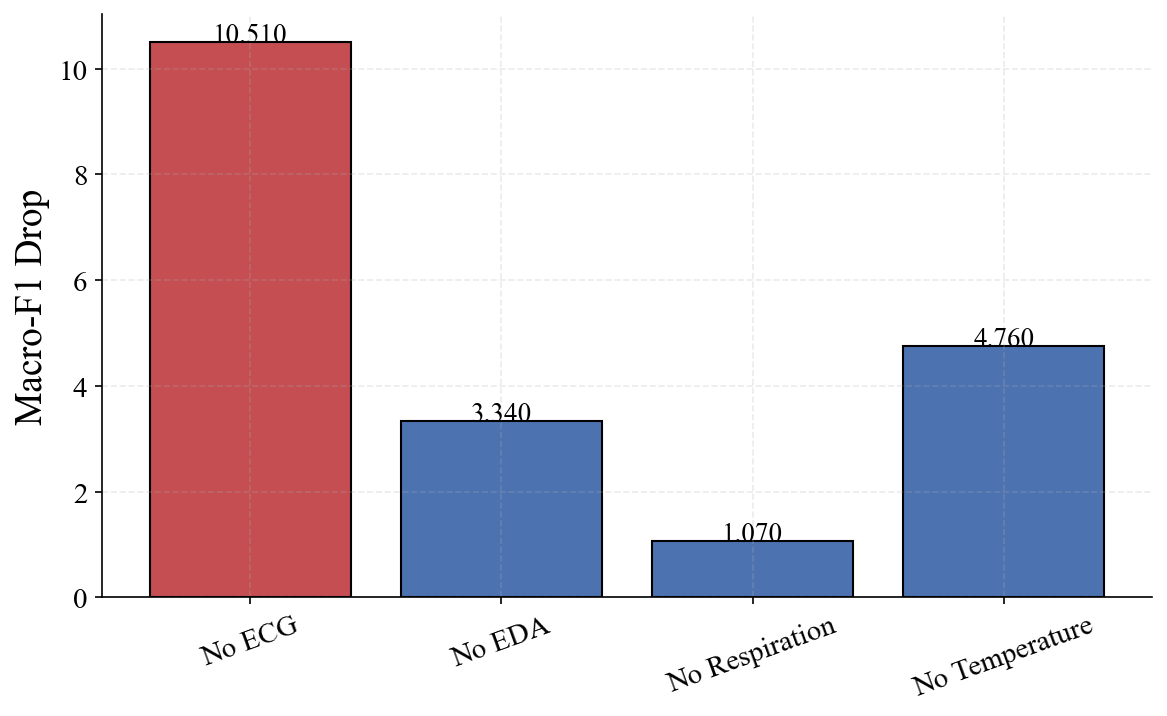

In [17]:
fig, ax = plt.subplots(figsize=(8,5))

colors = [
    RED if s=="No ECG" else BLUE
    for s in drop["Scenario"]
]

bars = ax.bar(
    drop["Scenario"],
    drop["mean"],
    color=colors,
    edgecolor="black"
)

ax.set_ylabel("Macro-F1 Drop")

ax.set_xlabel("")

plt.xticks(rotation=20)

for bar in bars:

    h = bar.get_height()

    ax.text(
        bar.get_x()+bar.get_width()/2,
        h+0.002,
        f"{h:.3f}",
        ha="center",
        fontsize=13
    )

plt.tight_layout()

plt.savefig("../results/figures/fig2_modality_importance.png")

plt.savefig("../results/figures/fig2_modality_importance.pdf")

plt.show()

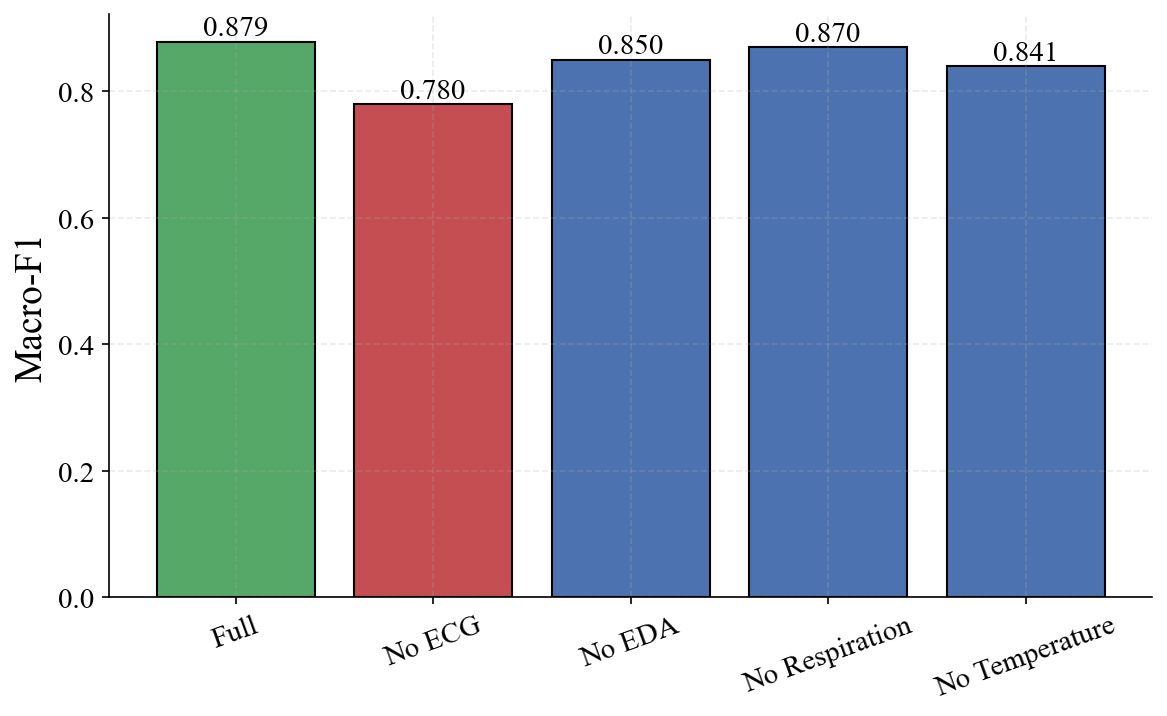

In [18]:
fig, ax = plt.subplots(figsize=(8,5))

colors = []

for s in single["Scenario"]:

    if s=="Full":

        colors.append(GREEN)

    elif s=="No ECG":

        colors.append(RED)

    else:

        colors.append(BLUE)

bars = ax.bar(

    single["Scenario"],

    single["F1"],

    color=colors,

    edgecolor="black"

)

ax.set_ylabel("Macro-F1")

plt.xticks(rotation=20)

for bar in bars:

    h=bar.get_height()

    ax.text(

        bar.get_x()+bar.get_width()/2,

        h+0.01,

        f"{h:.3f}",

        ha="center"

    )

plt.tight_layout()

plt.savefig("../results/figures/single_dropout_F1.png")

plt.show()

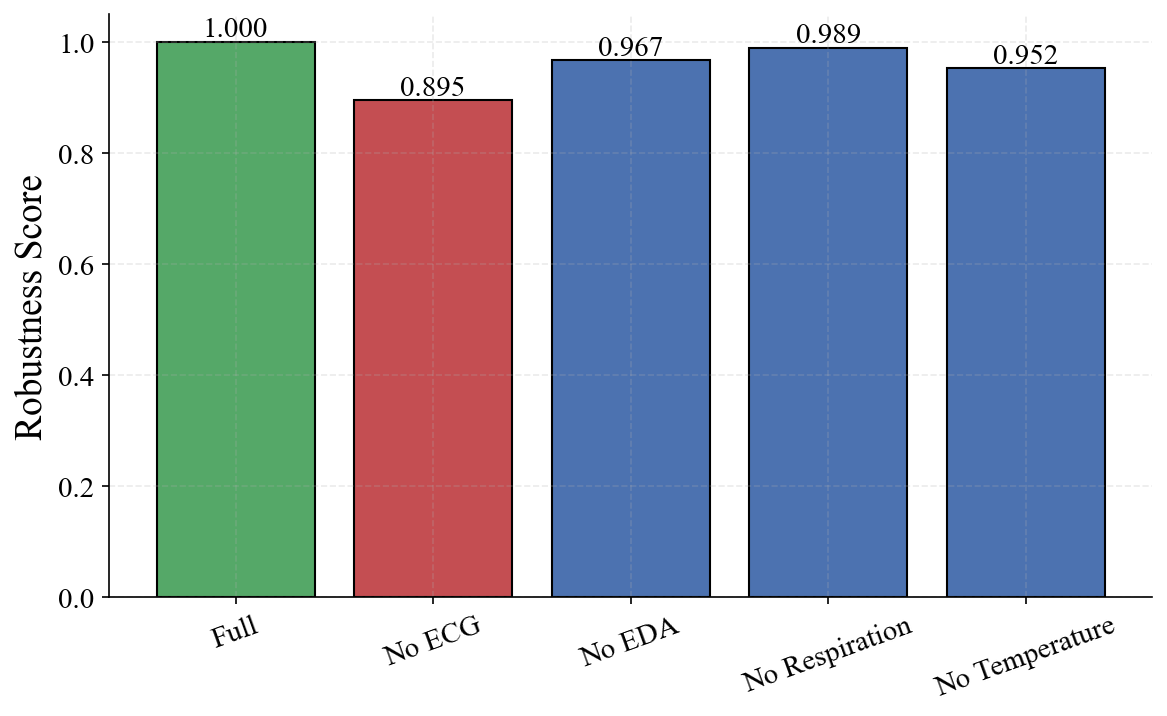

In [19]:
fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(

    single["Scenario"],

    single["RS"],

    color=colors,

    edgecolor="black"

)

ax.set_ylabel("Robustness Score")

plt.xticks(rotation=20)

for bar in bars:

    h=bar.get_height()

    ax.text(

        bar.get_x()+bar.get_width()/2,

        h+0.01,

        f"{h:.3f}",

        ha="center"

    )

plt.tight_layout()

plt.savefig("../results/figures/single_dropout_RS.png")

plt.show()

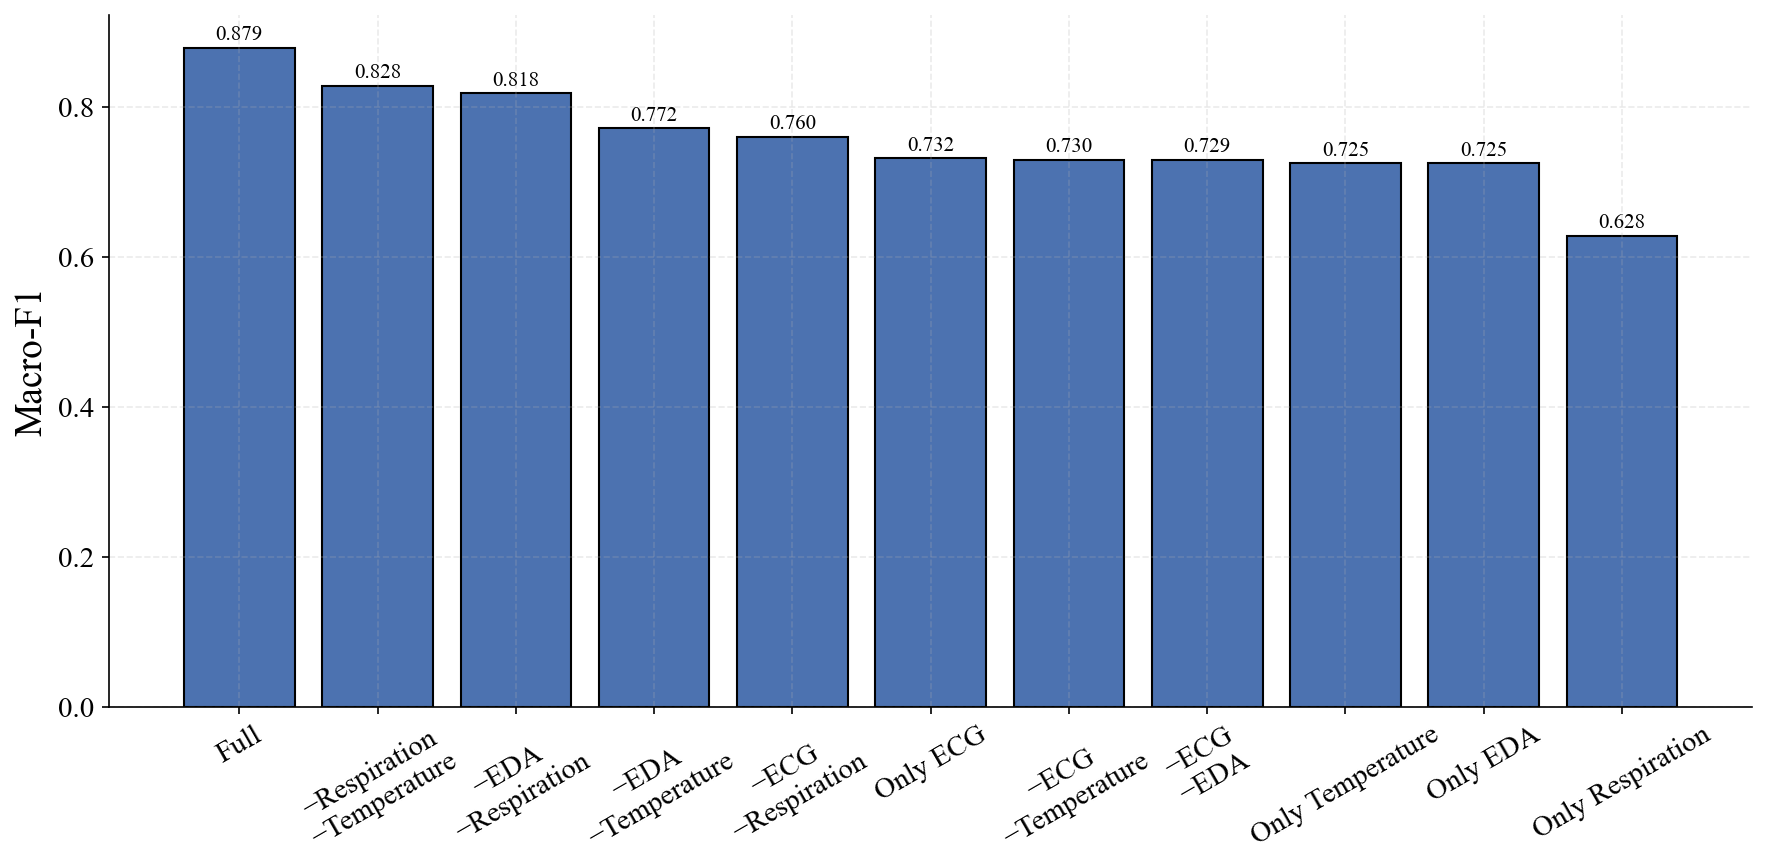

In [20]:
multi = multi.sort_values("F1Mean",ascending=False)

labels = [

s.replace("No ","−")

.replace(" + ","\n")

for s in multi["Scenario"]

]

fig, ax = plt.subplots(figsize=(12,6))

bars = ax.bar(

    labels,

    multi["F1Mean"],

    color=BLUE,

    edgecolor="black"

)

ax.set_ylabel("Macro-F1")

plt.xticks(rotation=30)

for bar in bars:

    h=bar.get_height()

    ax.text(

        bar.get_x()+bar.get_width()/2,

        h+0.01,

        f"{h:.3f}",

        ha="center",

        fontsize=10

    )

plt.tight_layout()

plt.savefig("../results/figures/multi_dropout_F1.png")

plt.show()

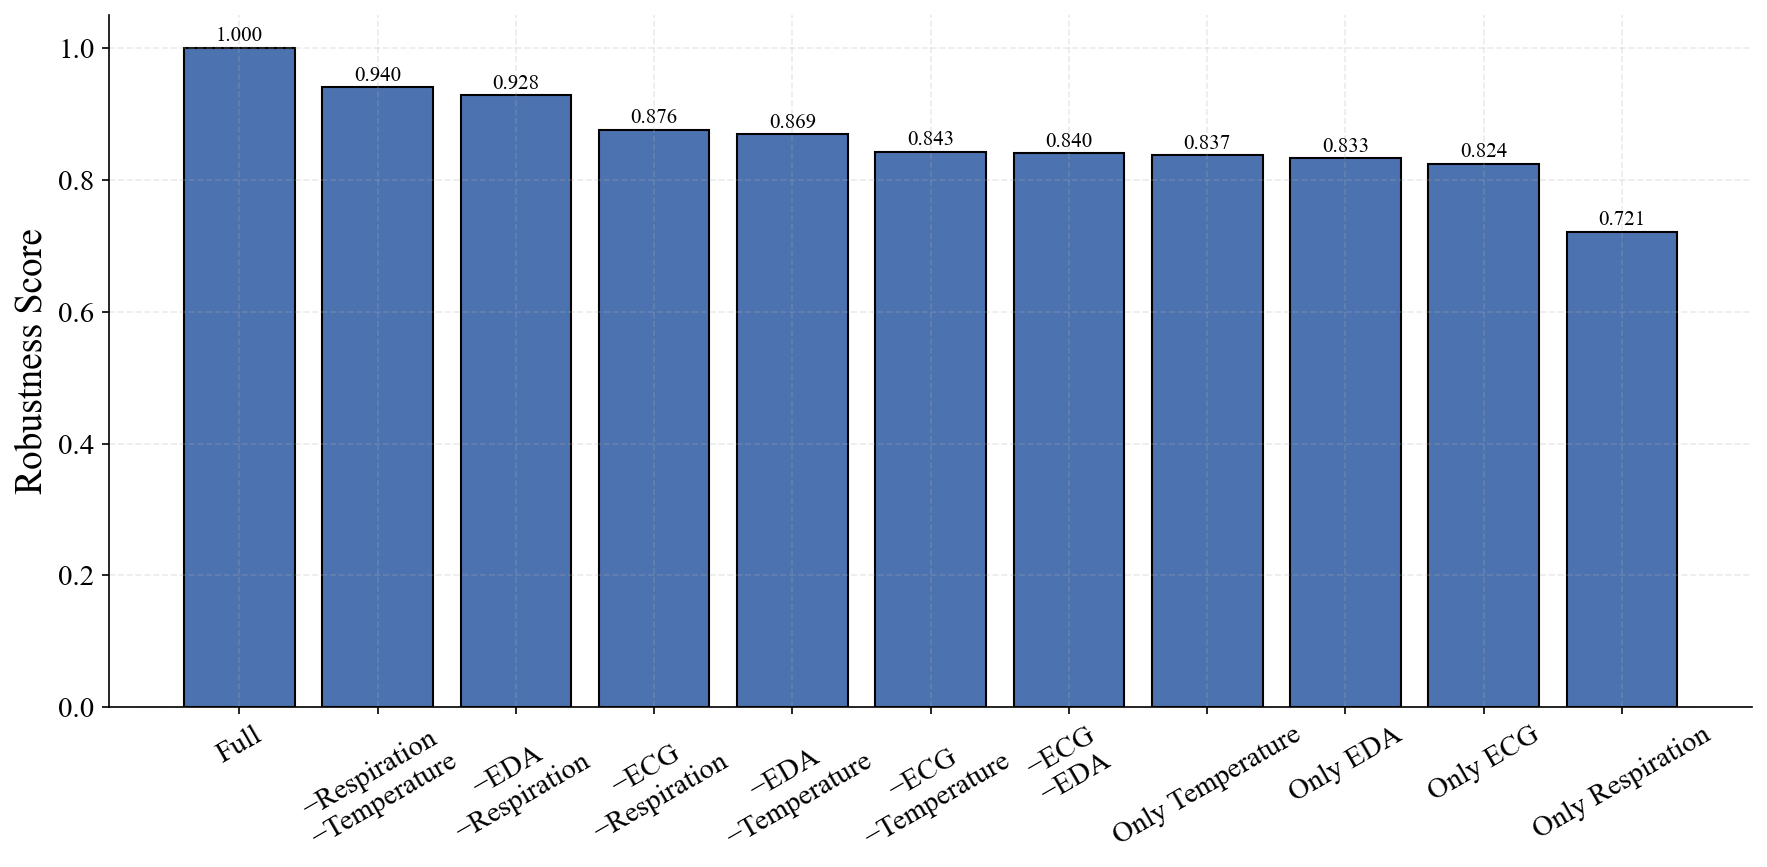

In [21]:
multi = multi.sort_values("RSMean",ascending=False)

labels = [

s.replace("No ","−")

.replace(" + ","\n")

for s in multi["Scenario"]

]

fig, ax = plt.subplots(figsize=(12,6))

bars = ax.bar(

    labels,

    multi["RSMean"],

    color=BLUE,

    edgecolor="black"

)

ax.set_ylabel("Robustness Score")

plt.xticks(rotation=30)

for bar in bars:

    h=bar.get_height()

    ax.text(

        bar.get_x()+bar.get_width()/2,

        h+0.01,

        f"{h:.3f}",

        ha="center",

        fontsize=10

    )

plt.tight_layout()

plt.savefig("../results/figures/multi_dropout_RS.png")

plt.show()